## Automatidata project

**Course 3 - Go Beyond the Numbers: Translate Data into Insights**

You are the newest data professional in a fictional data consulting firm: Automatidata. The team is still early into the project, having only just completed an initial plan of action and some early Python coding work.

Luana Rodriquez, the senior data analyst at Automatidata, is pleased with the work you have already completed and requests your assistance with some EDA and data visualization work for the New York City Taxi and Limousine Commission project (New York City TLC) to get a general understanding of what taxi ridership looks like. The management team is asking for a Python notebook showing data structuring and cleaning, as well as any matplotlib/seaborn visualizations plotted to help understand the data. At the very least, include a box plot of the ride durations and some time series plots, like a breakdown by quarter or month.

Additionally, the management team has recently asked all EDA to include Tableau visualizations. For this taxi data, create a Tableau dashboard showing a New York City map of taxi/limo trips by month. Make sure it is easy to understand to someone who isn’t data savvy, and remember that the assistant director at the New York City TLC is a person with visual impairments.

The purpose of this project is to conduct exploratory data analysis on a provided data set. The mission is to continue the investigation began in Course 2 and perform further EDA on this data with the aim of learning more about the variables.

The goal is to clean data set and create a visualization.

This activity has 4 parts:

Part 1: Imports, links, and loading

Part 2: Data Exploration
- Data cleaning

Part 3: Building visualizations

Part 4: Evaluate and share results

**Visualize a story in Tableau and Python**
The following notebook components are labeled with the respective PACE stage: Plan, Analyze, Construct, and Execute.

**PACE: Plan**
**Identify any outliers:**

**What methods are best for identifying outliers?**

- Use numpy functions to investigate the mean() and median() of the data and understand range of data values. 
- Use a boxplot to visualize the distribution of the data. 
- Use histograms to visualize the distribution of the data.

**How do you make the decision to keep or exclude outliers from any future models?**

There are three main options for dealing with outliers: keeping them as they are, deleting them, or reassigning them. Whether we keep outliers as they are, delete them, or reassign values is a decision that we make taking into account the nature of the outlying data and the assumptions of the model we are building. To make the decision, we can start with these general guidelines:

**Delete them:** If we are sure the outliers are mistakes, typos, or errors and the dataset will be used for modeling or machine learning, then we are more likely to decide to delete outliers. Of the three choices, we’ll use this one the least. 
**Reassign them:** If the dataset is small and/or the data will be used for modeling or machine learning, we are more likely to choose a path of deriving new values to replace the outlier values. 
**Leave them:** For a dataset that we plan to do EDA/analysis on and nothing else, or for a dataset we are preparing for a model that is resistant to outliers, it is most likely that we are going to leave them in.

In [1]:
# Import packages and libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import seaborn as sns

In [2]:
# Load dataset into dataframe
df = pd.read_csv('2017_Yellow_Taxi_Trip_Data.csv')
df.head()

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,24870114,2,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56
1,35634249,1,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80
2,106203690,1,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75
3,38942136,2,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.0,0.3,27.69
4,30841670,2,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,1,4.37,1,N,4,112,2,16.5,0.5,0.5,0.00,0.0,0.3,17.80


In [3]:
#Rename TripID
df.rename(columns = {'Unnamed: 0' : 'TripId'}, inplace = True)
df.head()

,TripId,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,24870114,2,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56
1,35634249,1,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80
2,106203690,1,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75
3,38942136,2,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.0,0.3,27.69
4,30841670,2,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,1,4.37,1,N,4,112,2,16.5,0.5,0.5,0.00,0.0,0.3,17.80


In [4]:
#Get statistics of the data
df.describe()

,TripId,VendorID,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
count,2.269900e+04,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000
mean,5.675849e+07,1.556236,1.642319,2.913313,1.043394,162.412353,161.527997,1.336887,13.026629,0.333275,0.497445,1.835781,0.312542,0.299551,16.310502
std,3.274493e+07,0.496838,1.285231,3.653171,0.708391,66.633373,70.139691,0.496211,13.243791,0.463097,0.039465,2.800626,1.399212,0.015673,16.097295
min,1.212700e+04,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,-120.000000,-1.000000,-0.500000,0.000000,0.000000,-0.300000,-120.300000
25%,2.852056e+07,1.000000,1.000000,0.990000,1.000000,114.000000,112.000000,1.000000,6.500000,0.000000,0.500000,0.000000,0.000000,0.300000,8.750000
50%,5.673150e+07,2.000000,1.000000,1.610000,1.000000,162.000000,162.000000,1.000000,9.500000,0.000000,0.500000,1.350000,0.000000,0.300000,11.800000
75%,8.537452e+07,2.000000,2.000000,3.060000,1.000000,233.000000,233.000000,2.000000,14.500000,0.500000,0.500000,2.450000,0.000000,0.300000,17.800000
max,1.134863e+08,2.000000,6.000000,33.960000,99.000000,265.000000,265.000000,4.000000,999.990000,4.500000,0.500000,200.000000,19.100000,0.300000,1200.290000


**Task 2b. Assess whether dimensions and measures are correct**
On the data source page in Tableau, double check the data types for the applicable columns selected on the previous step. Pay close attention to the dimensions and measures to assure they are correct.

In Python, consider the data types of the columns. Consider: Do they make sense?

Review the link provided in the previous activity instructions to create the required Tableau visualization.

**Task 2c. Select visualization type(s)**
Select data visualization types that will help you understand and explain the data.

Now that we know which data columns we’ll use, it is time to decide which data visualization makes the most sense for EDA of the TLC dataset. What type of data visualization(s) would be most helpful?

Line graph
Bar chart
Box plot
Histogram
Heat map
Scatter plot
A geographic map
A bar chart, box plot and scatter plot will be most helpful in understanding of this data.

A box plot will be helpful to determine outliers and where the bulk of the data points reside in terms of trip_distance, duration, and total_amount

A scatter plot will be helpful to visualize the trends and patters and outliers of critical variables, such as trip_distance and total_amount

A bar chart will help determine average number of trips per month, weekday, weekend, etc.

**PACE: Construct**
**Task 3. Data visualization**
Assessed the data, and decided on which data variables are most applicable. It’s time to plot your visualization(s)!

**Boxplots**
Perform a check for outliers on relevant columns such as trip distance and trip duration.Some of the best ways to identify outliers are Boxplot and Histogram.

In [5]:
# convert your date columns to datetime in order to derive total trip duration.
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

In [6]:
df.head()

,TripId,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,24870114,2,2017-03-25 08:55:43,2017-03-25 09:09:47,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56
1,35634249,1,2017-04-11 14:53:28,2017-04-11 15:19:58,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80
2,106203690,1,2017-12-15 07:26:56,2017-12-15 07:34:08,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75
3,38942136,2,2017-05-07 13:17:59,2017-05-07 13:48:14,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.0,0.3,27.69
4,30841670,2,2017-04-15 23:32:20,2017-04-15 23:49:03,1,4.37,1,N,4,112,2,16.5,0.5,0.5,0.00,0.0,0.3,17.80


**Trip Distance**

<Axes: title={'center': 'Trip Distance Boxplot'}, xlabel='trip_distance'>

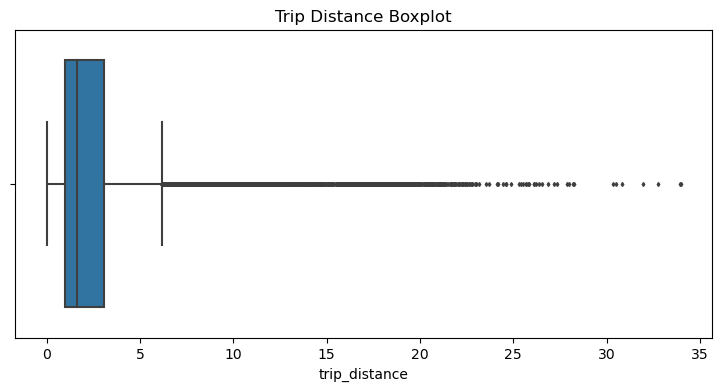

In [7]:
#Check for outliers using Boxplot
plt.figure(figsize=(9,4))
plt.title('Trip Distance Boxplot')
sns.boxplot(x=df['trip_distance'],fliersize=2)

<Axes: title={'center': 'Trip Distance Histogram'}, xlabel='trip_distance', ylabel='Count'>

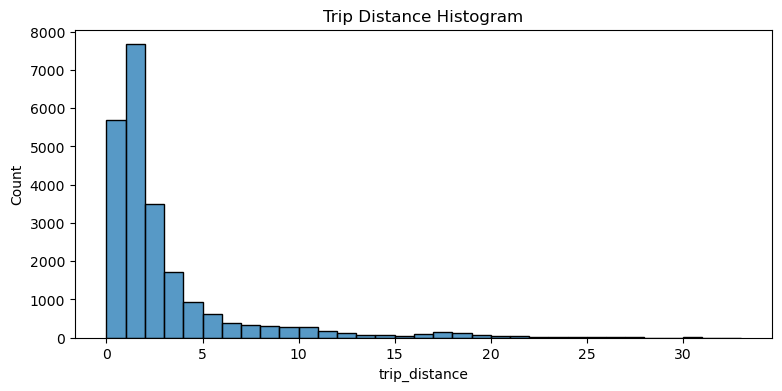

In [8]:
# Create histogram of trip_distance
plt.figure(figsize=(9,4))
plt.title('Trip Distance Histogram')
sns.histplot(x=df['trip_distance'], bins = range(0,34,1))

**total amount**

<Axes: title={'center': 'Total Amount Boxplot'}, xlabel='total_amount'>

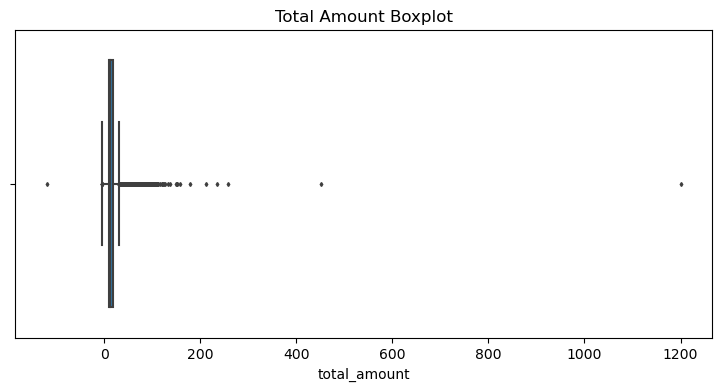

In [9]:
# Create box plot of total_amount
plt.figure(figsize=(9,4))
plt.title('Total Amount Boxplot')
sns.boxplot(x=df['total_amount'],fliersize=2)

Text(0.5, 1.0, 'Total Amount Histogram')

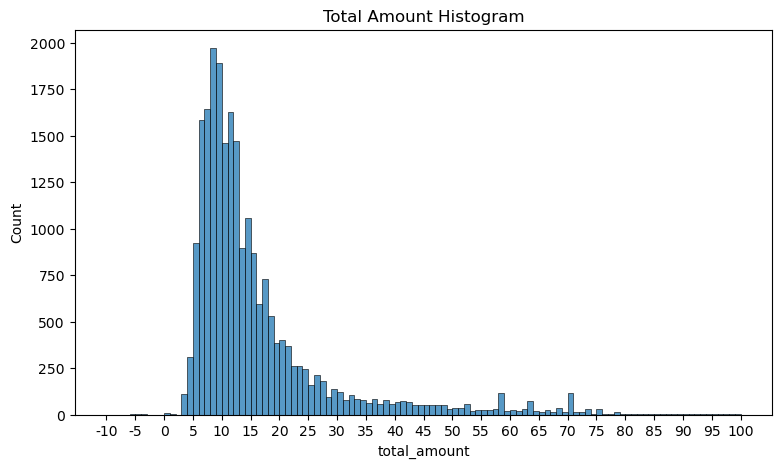

In [10]:
plt.figure(figsize=(9,5))

ax = sns.histplot(x=df['total_amount'], bins = range(-10,101,1))
ax.set_xticks(range(-10,101,5))
ax.set_xticklabels(range(-10,101,5))
plt.title('Total Amount Histogram')

**tip amount**

<Axes: title={'center': 'Tip Amount Boxplot'}, xlabel='tip_amount'>

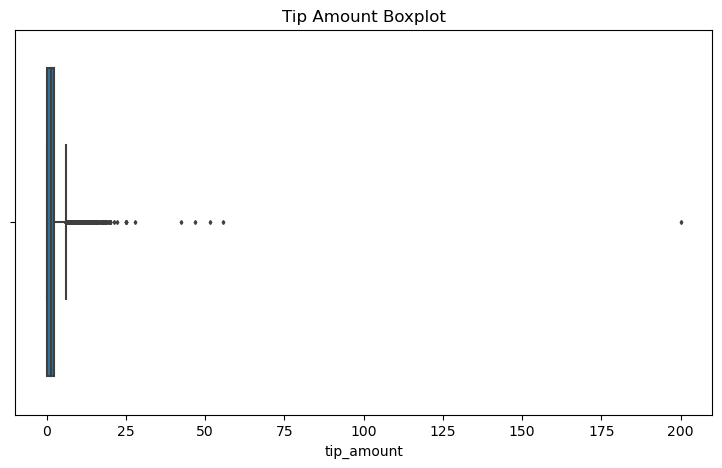

In [11]:
# Create box plot of tip_amount
plt.figure(figsize=(9,5))
plt.title('Tip Amount Boxplot')
sns.boxplot(x=df['tip_amount'],fliersize=2)

Text(0.5, 1.0, 'Tip Amount Histogram')

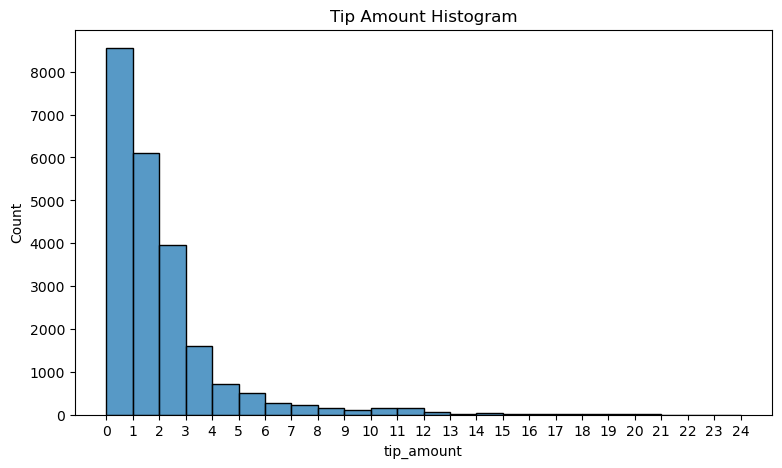

In [12]:
# Create histogram of tip_amount
plt.figure(figsize=(9,5))

ax = sns.histplot(x=df['tip_amount'], bins = range(0,25,1))
ax.set_xticks(range(0,25,1))
ax.set_xticklabels(range(0,25,1))
plt.title('Tip Amount Histogram')

**tip_amount by vendor**

Text(0.5, 1.0, 'Tip Amount by vendor histogram')

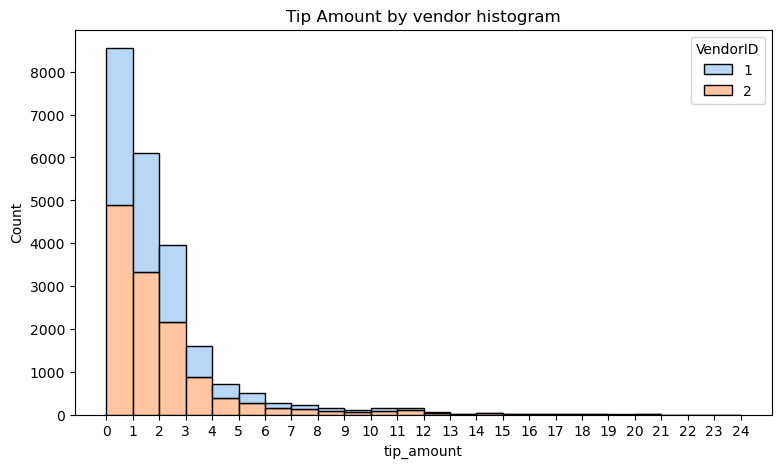

In [13]:
# Create histogram of tip_amount by vendor
plt.figure(figsize=(9,5))

ax = sns.histplot(data =df, x=df['tip_amount'], bins = range(0,25,1),
                 hue='VendorID',
                 multiple='stack',
                 palette='pastel')
ax.set_xticks(range(0,25,1))
ax.set_xticklabels(range(0,25,1))
plt.title('Tip Amount by vendor histogram')

Next, zoom in on the upper end of the range of tips to check whether vendor one gets noticeably more of the most generous tips.

Text(0.5, 1.0, 'Tip Amount by vendor histogram')

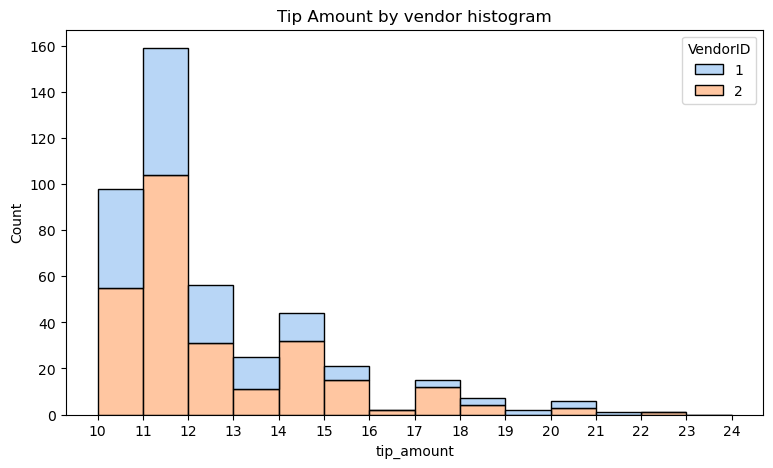

In [14]:
# Create histogram of tip_amount by vendor for tips > $10 
plt.figure(figsize=(9,5))

ax = sns.histplot(data =df[df['tip_amount'] > 10], x='tip_amount', bins = range(10,25,1),
                 hue='VendorID',
                 multiple='stack',
                 palette='pastel')
ax.set_xticks(range(10,25,1))
ax.set_xticklabels(range(10,25,1))
plt.title('Tip Amount by vendor histogram')

**Mean tips by passenger count**

In [15]:
#Examine the unique values in the passenger_count column.
df['passenger_count'].value_counts()

1    16117
2     3305
5     1143
3      953
6      693
4      455
0       33
Name: passenger_count, dtype: int64

In [16]:
# Calculate mean tips by passenger_count
mean_tips_by_passenger_count  = df.groupby('passenger_count')[['tip_amount']].mean()
mean_tips_by_passenger_count 

,tip_amount
passenger_count,
0,2.135758
1,1.848920
2,1.856378
3,1.716768
4,1.530264
5,1.873185
6,1.720260


Text(0.5, 1.0, 'Mean tip amount by passenger count')

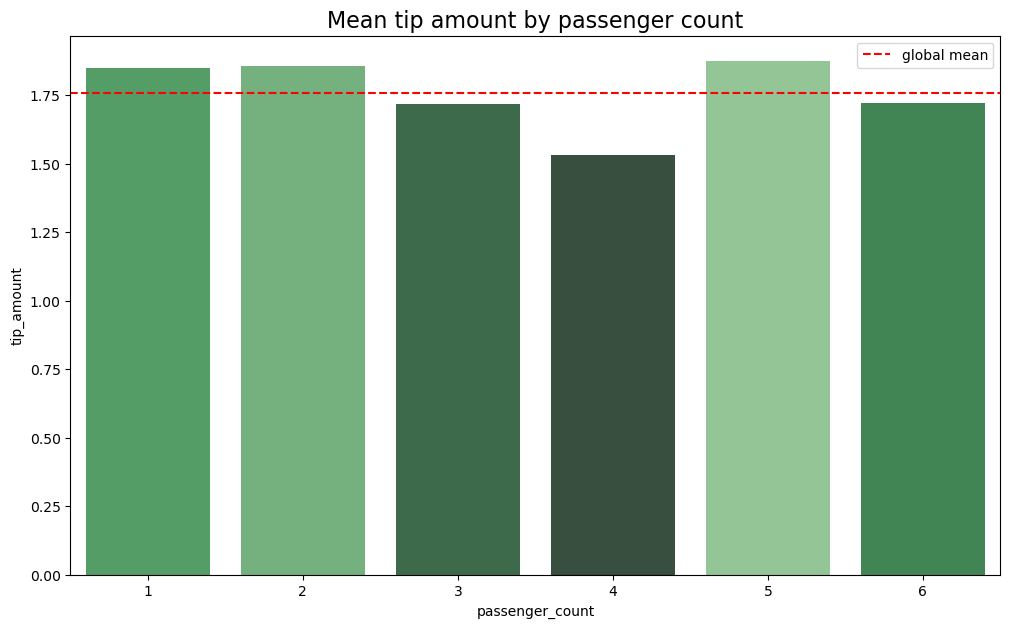

In [17]:
# Create bar plot for mean tips by passenger count
# mean_tips_by_passenger_count.tail(-1) -> to skip the first row
# After groupby passenger_count column will be index
# argsort() gives you the order of indices that would sort the values.

data = mean_tips_by_passenger_count.tail(-1)
pal = sns.color_palette('Greens_d',len(data))
rank = data['tip_amount'].argsort().argsort()
plt.figure(figsize=(12,7))

ax = sns.barplot(x=data.index,
            y=data['tip_amount'],
            palette = np.array(pal[::-1])[rank])
ax.axhline(data['tip_amount'].mean(), ls = '--', color = 'red', label = 'global mean')
ax.legend()

plt.title('Mean tip amount by passenger count', fontsize=16)

In [18]:
# Use the below code or
# data['tip_amount'].rank(method='dense', ascending=True).astype(int) - 1
# to produce 0‑based integer ranks
data['tip_amount'].argsort().argsort()

passenger_count
1    3
2    4
3    1
4    0
5    5
6    2
Name: tip_amount, dtype: int64

**Create month and day columns**

In [19]:
# Create a month column
df['tpep_pickup_month'] = df['tpep_pickup_datetime'].dt.month_name()

# Create a day column
df['tpep_pickup_day'] = df['tpep_pickup_datetime'].dt.day_name()

df.head()

,TripId,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,tpep_pickup_month,tpep_pickup_day
0,24870114,2,2017-03-25 08:55:43,2017-03-25 09:09:47,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56,March,Saturday
1,35634249,1,2017-04-11 14:53:28,2017-04-11 15:19:58,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80,April,Tuesday
2,106203690,1,2017-12-15 07:26:56,2017-12-15 07:34:08,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75,December,Friday
3,38942136,2,2017-05-07 13:17:59,2017-05-07 13:48:14,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.0,0.3,27.69,May,Sunday
4,30841670,2,2017-04-15 23:32:20,2017-04-15 23:49:03,1,4.37,1,N,4,112,2,16.5,0.5,0.5,0.00,0.0,0.3,17.80,April,Saturday


**Plot total ride count by month**

In [20]:
# Get total number of rides for each month
monthly_rides  = df['tpep_pickup_month'].value_counts()
monthly_rides 

March        2049
October      2027
April        2019
May          2013
January      1997
June         1964
December     1863
November     1843
February     1769
September    1734
August       1724
July         1697
Name: tpep_pickup_month, dtype: int64

Reorder the results to put the months in calendar order.

In [21]:
# Reorder the monthly ride list so months go in order
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July',
         'August', 'September', 'October', 'November', 'December']

monthly_rides = monthly_rides.reindex(index=month_order)
monthly_rides


January      1997
February     1769
March        2049
April        2019
May          2013
June         1964
July         1697
August       1724
September    1734
October      2027
November     1843
December     1863
Name: tpep_pickup_month, dtype: int64

In [22]:
# Show the index
monthly_rides.index

Index(['January', 'February', 'March', 'April', 'May', 'June', 'July',
       'August', 'September', 'October', 'November', 'December'],
      dtype='object')

Text(0.5, 1.0, 'Ride count by month')

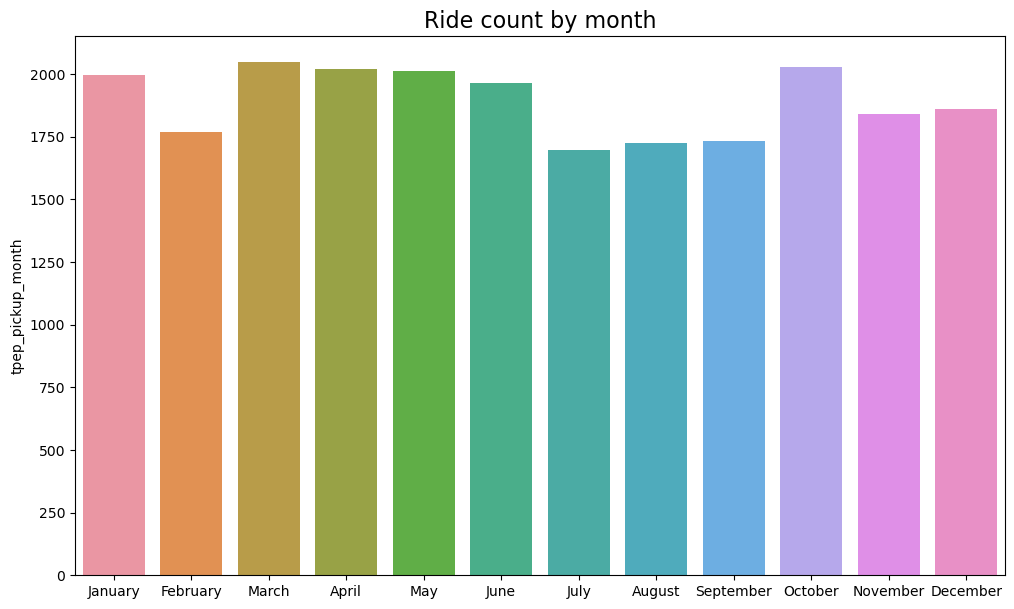

In [23]:
# Create a bar plot of total rides per month
plt.figure(figsize=(12,7))
ax=sns.barplot(x=monthly_rides.index,
           y=monthly_rides)
ax.set_xticklabels(month_order)
plt.title('Ride count by month', fontsize=16)

**Plot total ride count by day**
Repeat the above process, but now calculate the total rides by day of the week.

In [24]:
# Get total number of rides for each day
daily_rides  = df['tpep_pickup_day'].value_counts()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

daily_rides = daily_rides.reindex(index=day_order)
daily_rides

Monday       2931
Tuesday      3198
Wednesday    3390
Thursday     3402
Friday       3413
Saturday     3367
Sunday       2998
Name: tpep_pickup_day, dtype: int64

Text(0.5, 1.0, 'Ride count by Day')

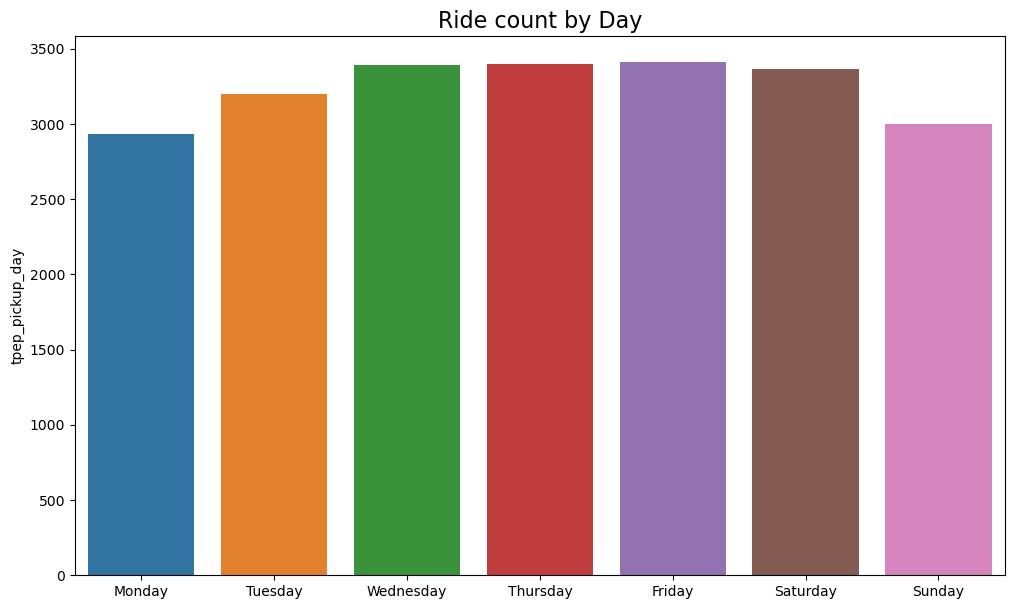

In [25]:
# Create bar plot for ride count by day
plt.figure(figsize=(12,7))
ax=sns.barplot(x=daily_rides.index,
           y=daily_rides)
ax.set_xticklabels(day_order)
plt.title('Ride count by Day', fontsize=16)

**Plot total revenue by day of the week**
Repeat the above process, but now calculate the total revenue by day of the week.

In [26]:
# Repeat the process, this time for total revenue by day
total_amount_day  = df.groupby('tpep_pickup_day')[['total_amount']].sum()
total_amount_day = total_amount_day.reindex(index= day_order)
total_amount_day

,total_amount
tpep_pickup_day,
Monday,49574.37
Tuesday,52527.14
Wednesday,55310.47
Thursday,57181.91
Friday,55818.74
Saturday,51195.40
Sunday,48624.06


Text(0.5, 1.0, 'Total Revenue by Day')

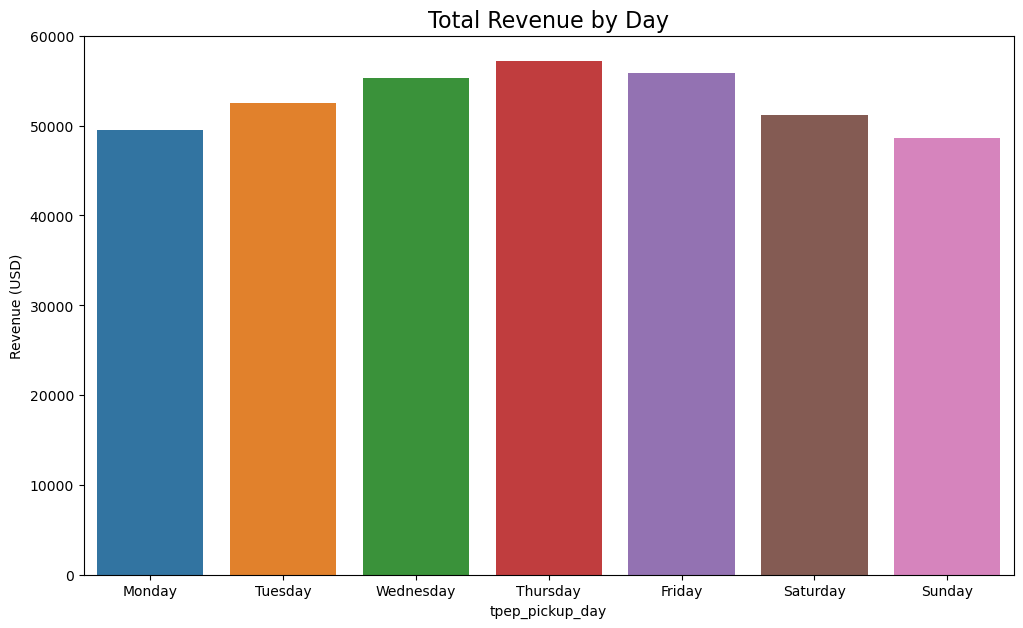

In [27]:
# Create bar plot of total revenue by day
plt.figure(figsize=(12,7))
ax=sns.barplot(x=total_amount_day.index,
           y=total_amount_day['total_amount'])
ax.set_xticklabels(day_order)
ax.set_ylabel('Revenue (USD)')
plt.title('Total Revenue by Day', fontsize=16)

**Plot total revenue by month**

In [28]:
# Repeat the process, this time for total revenue by month
total_amount_month  = df.groupby('tpep_pickup_month')[['total_amount']].sum()
total_amount_month = total_amount_month.reindex(index= month_order)
total_amount_month

,total_amount
tpep_pickup_month,
January,31735.25
February,28937.89
March,33085.89
April,32012.54
May,33828.58
June,32920.52
July,26617.64
August,27759.56
September,28206.38


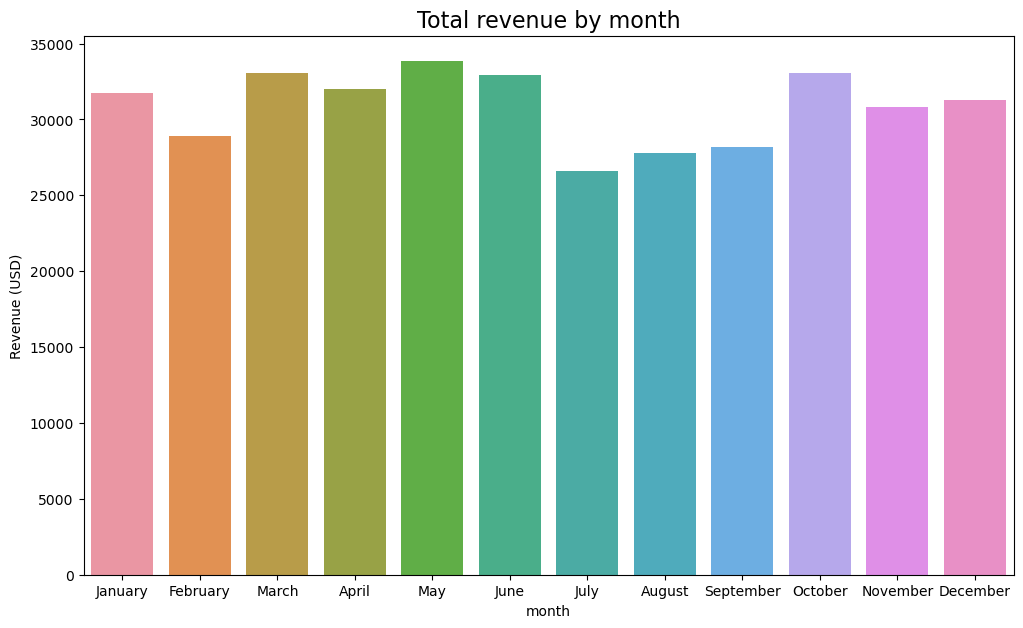

In [29]:
# Create a bar plot of total revenue by month
plt.figure(figsize=(12,7))
ax = sns.barplot(x = total_amount_month.index,
           y = total_amount_month['total_amount'])
ax.set_xticklabels(month_order)
ax.set_xlabel('month')
ax.set_ylabel('Revenue (USD)')
plt.title('Total revenue by month', fontsize=16);

**Plot mean trip distance by drop-off location**

In [30]:
# Calculate the mean trip distance for each drop-off location
distance_drop_off  = df.groupby('DOLocationID')[['trip_distance']].mean()

distance_drop_off = distance_drop_off.sort_values(by = 'trip_distance')
distance_drop_off

,trip_distance
DOLocationID,
207,1.200000
193,1.390556
237,1.555494
234,1.727806
137,1.818852
...,...
51,17.310000
11,17.945000
210,20.500000


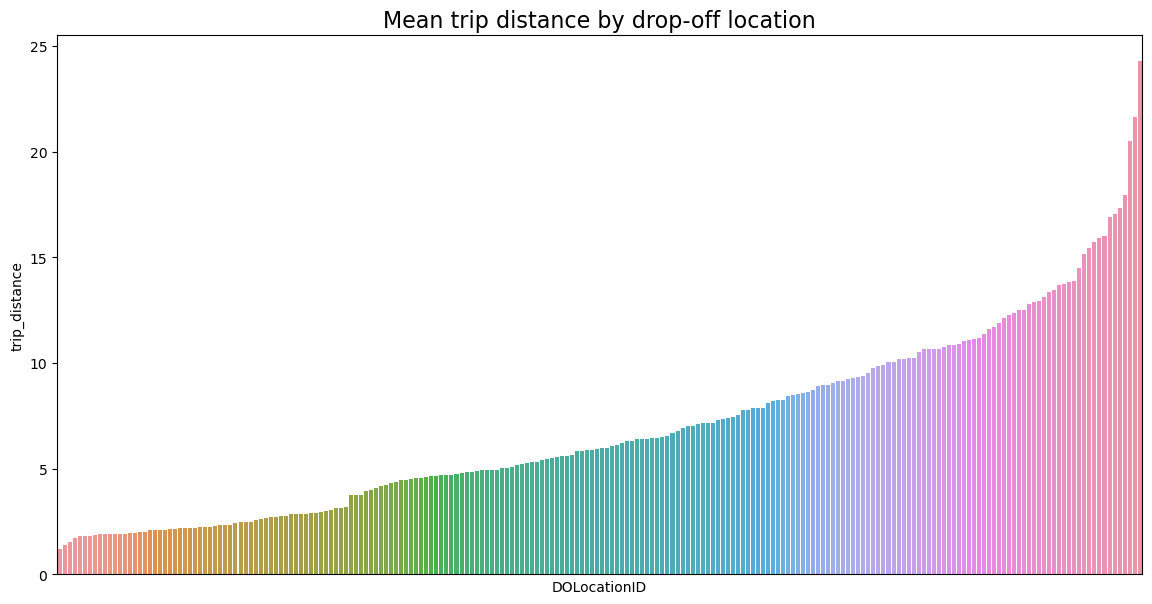

In [31]:
# Create a bar plot of mean trip distances by drop-off location in ascending order by distance
plt.figure(figsize=(14,7))
ax = sns.barplot(x = distance_drop_off.index,
           y = distance_drop_off['trip_distance'],
           order=distance_drop_off.index)
ax.set_xticks([])
plt.title('Mean trip distance by drop-off location', fontsize=16);

**Histogram of rides by drop-off location**
First, check to whether the drop-off locations IDs are consecutively numbered. For instance, does it go 1, 2, 3, 4..., or are some numbers missing (e.g., 1, 3, 4...). If numbers aren't all consecutive, the histogram will look like some locations have very few or no rides when in reality there's no bar because there's no location.

In [32]:
# Check if all drop-off locations are consecutively numbered
df['DOLocationID'].max()

265

In [34]:
len(df['DOLocationID'].unique())

216

In [35]:
df['DOLocationID'].max() - len(df['DOLocationID'].unique())

49

To eliminate the spaces in the historgram that these missing numbers would create, sort the unique drop-off location values, then convert them to strings. This will make the histplot function display all bars directly next to each other.

<Axes: xlabel='DOLocationID', ylabel='Count'>

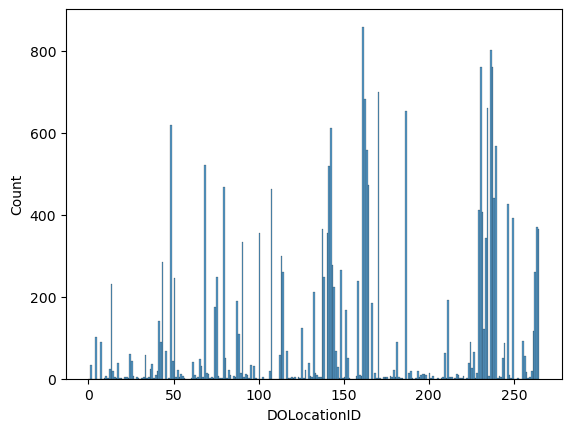

In [36]:
sns.histplot(data = df['DOLocationID'], bins = range(0,df['DOLocationID'].max()+1,1))

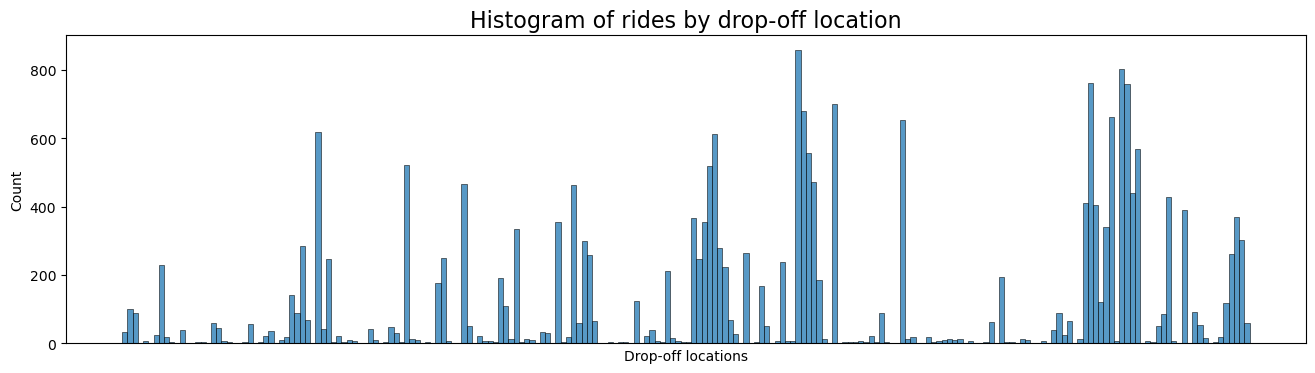

In [38]:
plt.figure(figsize=(16,4))
sorted_dropoffs = df['DOLocationID'].sort_values()
sorted_dropoffs = sorted_dropoffs.astype('str')
sns.histplot(data = sorted_dropoffs, bins = range(0,df['DOLocationID'].max()+1,1))
plt.xticks([])
plt.xlabel('Drop-off locations')
plt.title('Histogram of rides by drop-off location', fontsize=16);

In [44]:
#get the trip duraion in minutues
df['trip_duration_min'] = (df['tpep_dropoff_datetime']-df['tpep_pickup_datetime']).dt.total_seconds() / 60
df.head()

,TripId,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,tpep_pickup_month,tpep_pickup_day,trip_duration,trip_duration_min
0,24870114,2,2017-03-25 08:55:43,2017-03-25 09:09:47,6,3.34,1,N,100,231,...,0.0,0.5,2.76,0.0,0.3,16.56,March,Saturday,14.066667,14.066667
1,35634249,1,2017-04-11 14:53:28,2017-04-11 15:19:58,1,1.80,1,N,186,43,...,0.0,0.5,4.00,0.0,0.3,20.80,April,Tuesday,26.500000,26.500000
2,106203690,1,2017-12-15 07:26:56,2017-12-15 07:34:08,1,1.00,1,N,262,236,...,0.0,0.5,1.45,0.0,0.3,8.75,December,Friday,7.200000,7.200000
3,38942136,2,2017-05-07 13:17:59,2017-05-07 13:48:14,1,3.70,1,N,188,97,...,0.0,0.5,6.39,0.0,0.3,27.69,May,Sunday,30.250000,30.250000
4,30841670,2,2017-04-15 23:32:20,2017-04-15 23:49:03,1,4.37,1,N,4,112,...,0.5,0.5,0.00,0.0,0.3,17.80,April,Saturday,16.716667,16.716667


**PACE: Execute**
Consider the questions in PACE Strategy Document to reflect on the Execute stage.

**Results and evaluation**
Having built visualizations in Tableau and in Python, what have you learned about the dataset? What other questions have your visualizations uncovered that you should pursue?

1. Most trips cluster under 5 miles, but the long‑tail outliers stretch much farther
2. Several records show a trip distance of 0.0 miles. What could these zero‑distance trips represent, and how might they affect the accuracy of any models we build?

**Conclusion**
Why is it important to conduct Exploratory Data Analysis? Why are the data visualizations provided in this notebook useful?
1. Exploratory Data Analysis helps you become familiar with the dataset, identify outliers, assess data quality, and address issues like missing values or inconsistencies so the data is ready for reliable modeling.
2. The visualizations revealed several outliers in the dataset, which means we’ll need to decide how to handle these unusual values before developing any predictive models.”